In [1]:
# Install libraries

!pip install pandas nltk matplotlib wordcloud scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
# CREATING DATASETS

positive_reviews = ["The acting was outstanding.","The storyline was engaging.","The movie exceeded my expectations.","A wonderful cinematic experience.",
"Fantastic direction and screenplay.","The background music was excellent.","Visual effects were amazing.","The actors delivered brilliant performances.",
"I loved every moment of the movie.","Highly recommended movie.","The climax was emotional.","The comedy scenes were hilarious.",
"The movie kept me entertained throughout.","The screenplay was excellent.","Excellent action sequences.","The dialogues were powerful.",
"One of the best movies this year.","Great performances by the cast.","The movie was inspiring.","Absolutely worth watching."]

negative_reviews = ["The acting was terrible.","The storyline was boring.","The movie was disappointing.",
"Very slow screenplay.","Waste of time.","The music was irritating.","Poor direction.","The visual effects were terrible.",
"The ending was confusing.","Nothing interesting happened.","The dialogues were weak.","Poor acting by the lead actor.",
"The comedy was not funny.","The action scenes looked fake.","The movie was too lengthy.","Very predictable story.",
"The editing was poor.","I regret watching this movie.","Completely disappointing.","One of the worst movies."]

neutral_reviews = ["The movie was average.","It was okay.","The acting was decent.","The storyline was acceptable.",
"Nothing special about the movie.","It was a one-time watch.","The songs were fine.","Average direction.",
"The visual effects were okay.","The performances were decent.","The screenplay was average.","The movie met expectations.",
"It had both good and bad moments.","The ending was acceptable.","Nothing memorable.","The film was neither good nor bad.",
"The acting was normal.","The music was average.","The movie was satisfactory.","An average entertainment."]

In [5]:
reviews = []
ratings = []
sentiments = []

In [6]:
# Generate Positive Reviews

for i in range(500):
    review = " ".join(random.sample(positive_reviews,4))
    reviews.append(review)
    ratings.append(random.choice([4,5]))
    sentiments.append("Positive")

In [7]:
# Generate Negative Reviews

for i in range(300):
    review = " ".join(random.sample(negative_reviews,4))
    reviews.append(review)
    ratings.append(random.choice([1,2]))
    sentiments.append("Negative")

In [8]:
# Generate Neutral Reviews

for i in range(200):
    review = " ".join(random.sample(neutral_reviews,4))
    reviews.append(review)
    ratings.append(3)
    sentiments.append("Neutral")

In [9]:
combined = list(zip(reviews,ratings,sentiments))
random.shuffle(combined)
reviews,ratings,sentiments = zip(*combined)

In [10]:
df = pd.DataFrame({"Review":reviews,"Rating":ratings,"Sentiment":sentiments})

df.head()

,Review,Rating,Sentiment
0,Poor direction. The storyline was boring. The ...,1,Negative
1,The movie was disappointing. Very slow screenp...,1,Negative
2,One of the best movies this year. The dialogue...,5,Positive
3,The music was irritating. Very predictable sto...,1,Negative
4,Visual effects were amazing. Excellent action ...,4,Positive


In [11]:
df.shape

(1000, 3)

In [12]:
df.sample(10)

,Review,Rating,Sentiment
259,Poor acting by the lead actor. The editing was...,2,Negative
999,A wonderful cinematic experience. The movie wa...,4,Positive
32,One of the best movies this year. The comedy s...,4,Positive
141,Absolutely worth watching. Visual effects were...,4,Positive
495,The movie was inspiring. The actors delivered ...,5,Positive
487,Nothing memorable. An average entertainment. T...,3,Neutral
488,The storyline was engaging. The screenplay was...,5,Positive
38,The movie was too lengthy. Completely disappoi...,2,Negative
550,Fantastic direction and screenplay. I loved ev...,4,Positive
142,The background music was excellent. Excellent ...,5,Positive


In [13]:
df["Rating"].value_counts().sort_index()

,count
Rating,
1,147
2,153
3,200
4,247
5,253


NOW THE EDA PART

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     1000 non-null   object
 1   Rating     1000 non-null   int64 
 2   Sentiment  1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


In [15]:
df.isnull().sum()

,0
Review,0
Rating,0
Sentiment,0


In [16]:
df.duplicated().sum()

np.int64(0)

TEXT PREPROCESSING

In [18]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [19]:
def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words]
    return " ".join(words)

In [20]:
df["Cleaned_Review"] = df["Review"].apply(preprocess)

df.head()

,Review,Rating,Sentiment,Cleaned_Review
0,Poor direction. The storyline was boring. The ...,1,Negative,poor direction storyline boring music irritati...
1,The movie was disappointing. Very slow screenp...,1,Negative,movie disappointing slow screenplay ending con...
2,One of the best movies this year. The dialogue...,5,Positive,one best movie year dialogue powerful climax e...
3,The music was irritating. Very predictable sto...,1,Negative,music irritating predictable story poor direct...
4,Visual effects were amazing. Excellent action ...,4,Positive,visual effect amazing excellent action sequenc...


In [21]:
df[["Review","Cleaned_Review"]].head(10)

,Review,Cleaned_Review
0,Poor direction. The storyline was boring. The ...,poor direction storyline boring music irritati...
1,The movie was disappointing. Very slow screenp...,movie disappointing slow screenplay ending con...
2,One of the best movies this year. The dialogue...,one best movie year dialogue powerful climax e...
3,The music was irritating. Very predictable sto...,music irritating predictable story poor direct...
4,Visual effects were amazing. Excellent action ...,visual effect amazing excellent action sequenc...
5,The storyline was boring. Nothing interesting ...,storyline boring nothing interesting happened ...
6,The storyline was engaging. The movie was insp...,storyline engaging movie inspiring one best mo...
7,The movie was too lengthy. The movie was disap...,movie lengthy movie disappointing editing poor...
8,The storyline was boring. The ending was confu...,storyline boring ending confusing poor acting ...
9,The movie kept me entertained throughout. High...,movie kept entertained throughout highly recom...


In [25]:
df["Review_Length"] = df["Review"].apply(lambda x: len(x.split()))

df["Review_Length"].describe()

,Review_Length
count,1000.00000
mean,17.03800
std,2.32335
min,11.00000
25%,15.00000
50%,17.00000
75%,19.00000
max,25.00000


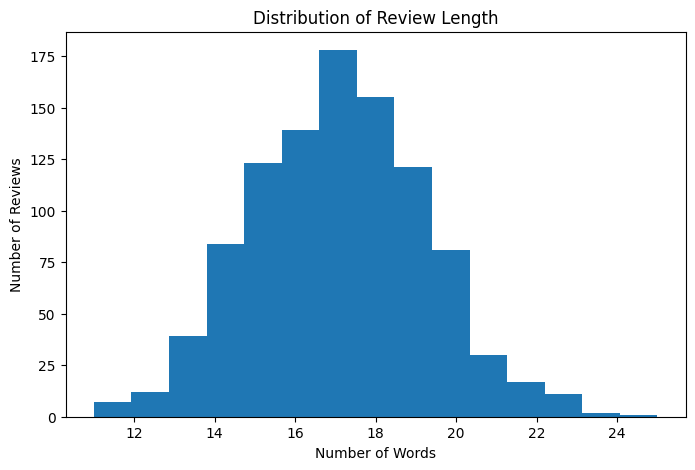

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df["Review_Length"], bins=15)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

In [27]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,500
Negative,300
Neutral,200


In [28]:
df.groupby("Sentiment")["Rating"].mean()

,Rating
Sentiment,
Negative,1.510
Neutral,3.000
Positive,4.506


In [29]:
df.groupby("Sentiment")["Review_Length"].mean()

,Review_Length
Sentiment,
Negative,16.030
Neutral,16.185
Positive,17.984


In [31]:
# MOST COMMON WORDS

from collections import Counter
words = " ".join(df["Cleaned_Review"]).split()
word_counts = Counter(words)
word_counts.most_common(20)

[('movie', 1003),
 ('excellent', 312),
 ('acting', 309),
 ('screenplay', 307),
 ('performance', 234),
 ('average', 221),
 ('direction', 220),
 ('music', 212),
 ('storyline', 203),
 ('visual', 194),
 ('effect', 194),
 ('poor', 184),
 ('scene', 171),
 ('action', 170),
 ('dialogue', 169),
 ('actor', 165),
 ('comedy', 158),
 ('watching', 155),
 ('one', 140),
 ('disappointing', 139)]

In [32]:
top_words = pd.DataFrame(word_counts.most_common(20),columns=["Word","Frequency"])
top_words

,Word,Frequency
0,movie,1003
1,excellent,312
2,acting,309
3,screenplay,307
4,performance,234
5,average,221
6,direction,220
7,music,212
8,storyline,203
9,visual,194


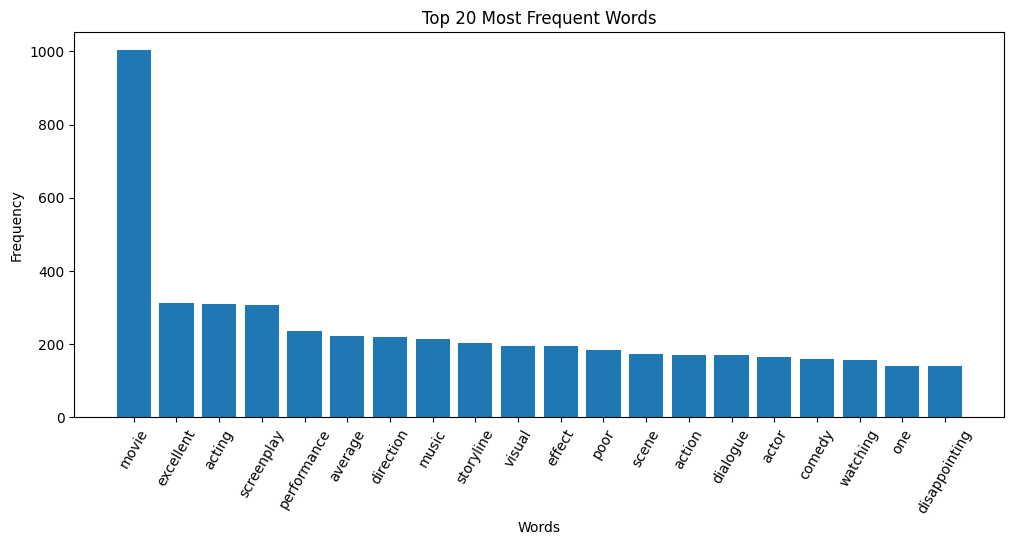

In [33]:
plt.figure(figsize=(12,5))
plt.bar(top_words["Word"], top_words["Frequency"])
plt.xticks(rotation=60)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [34]:
df.head()

,Review,Rating,Sentiment,Cleaned_Review,Review_Length
0,Poor direction. The storyline was boring. The ...,1,Negative,poor direction storyline boring music irritati...,13
1,The movie was disappointing. Very slow screenp...,1,Negative,movie disappointing slow screenplay ending con...,15
2,One of the best movies this year. The dialogue...,5,Positive,one best movie year dialogue powerful climax e...,20
3,The music was irritating. Very predictable sto...,1,Negative,music irritating predictable story poor direct...,13
4,Visual effects were amazing. Excellent action ...,4,Positive,visual effect amazing excellent action sequenc...,17


BUILDING SENTIMENT CLASSIFICATION MODEL

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [36]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

In [37]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)
print(X_tfidf.shape)

(1000, 92)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf,y,test_size=0.2,random_state=42)

In [40]:
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 800
Testing Samples : 200


In [41]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [42]:
predictions = model.predict(X_test)
predictions[:10]

array(['Positive', 'Neutral', 'Positive', 'Negative', 'Positive',
       'Neutral', 'Neutral', 'Positive', 'Positive', 'Negative'],
      dtype='<U8')

In [43]:
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy : {:.2f}%".format(accuracy*100))

Model Accuracy : 100.00%


In [44]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        63
     Neutral       1.00      1.00      1.00        38
    Positive       1.00      1.00      1.00        99

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [45]:
cm = confusion_matrix(y_test, predictions)
cm

array([[63,  0,  0],
       [ 0, 38,  0],
       [ 0,  0, 99]])

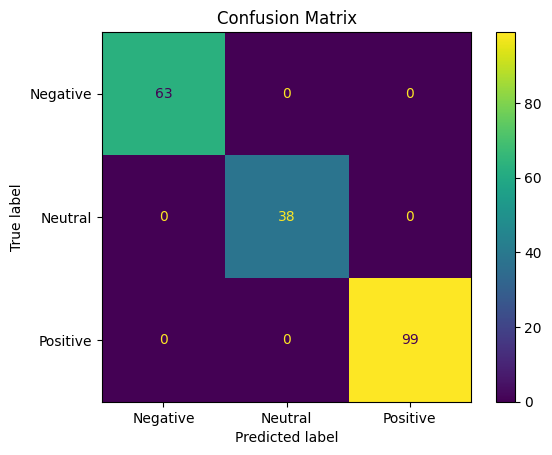

In [46]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

TESTING THEE SENTIMENT CLASSIFICATION MODEL

In [47]:
new_review = [
    "The acting was outstanding and the storyline was fantastic."
]
new_review

['The acting was outstanding and the storyline was fantastic.']

In [48]:
new_review_clean = [
    preprocess(review)
    for review in new_review
]

In [49]:
new_vector = tfidf.transform(new_review_clean)

In [50]:
prediction = model.predict(new_vector)
print("Predicted Sentiment :", prediction[0])

Predicted Sentiment : Positive


In [51]:
new_review = [
    "Worst movie ever. The acting was terrible and I regret watching it."
]
new_review_clean = [
    preprocess(review)
    for review in new_review
]
prediction = model.predict(
    tfidf.transform(new_review_clean)
)
print(prediction[0])

Negative


In [52]:
new_review = [
    "The movie was average. Nothing special."
]
new_review_clean = [
    preprocess(review)
    for review in new_review
]
prediction = model.predict(
    tfidf.transform(new_review_clean)
)
print(prediction[0])

Neutral


ANALYSING AUDIENCE OPTINIONS

In [53]:
sentiment_counts = df["Sentiment"].value_counts()
sentiment_counts

,count
Sentiment,
Positive,500
Negative,300
Neutral,200


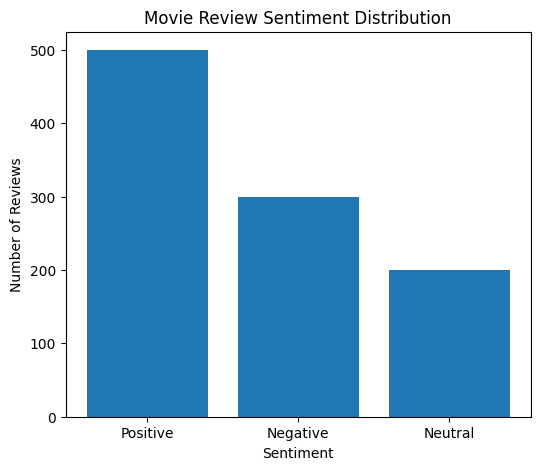

In [54]:
plt.figure(figsize=(6,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)
plt.title("Movie Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

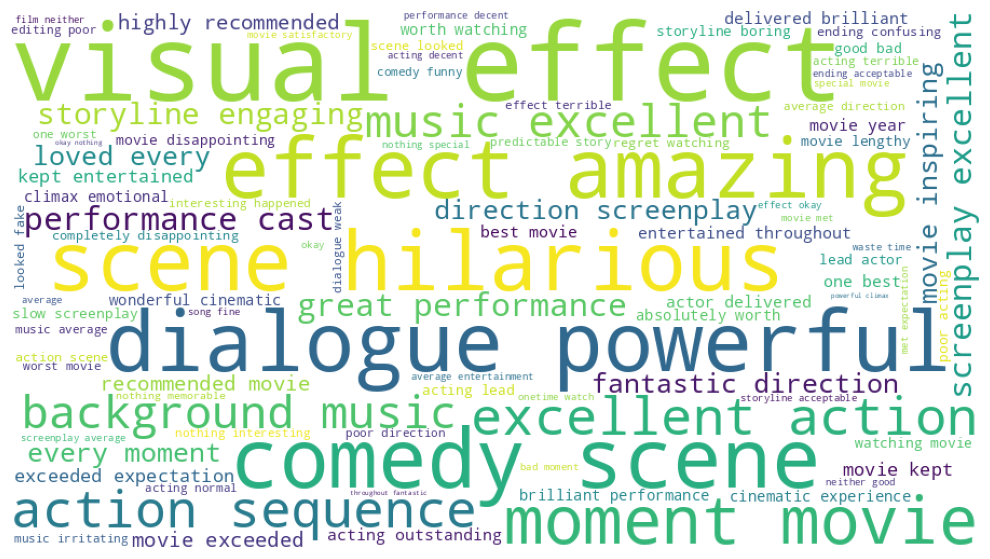

In [56]:
# WORD CLOUD

text = " ".join(df["Cleaned_Review"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [57]:
# FREQUENCTLY USED WORDS

from collections import Counter
words = text.split()
word_frequency = Counter(words)
top20 = word_frequency.most_common(20)
top20_df = pd.DataFrame(
    top20,
    columns=["Word","Frequency"]
)
top20_df

,Word,Frequency
0,movie,1003
1,excellent,312
2,acting,309
3,screenplay,307
4,performance,234
5,average,221
6,direction,220
7,music,212
8,storyline,203
9,visual,194


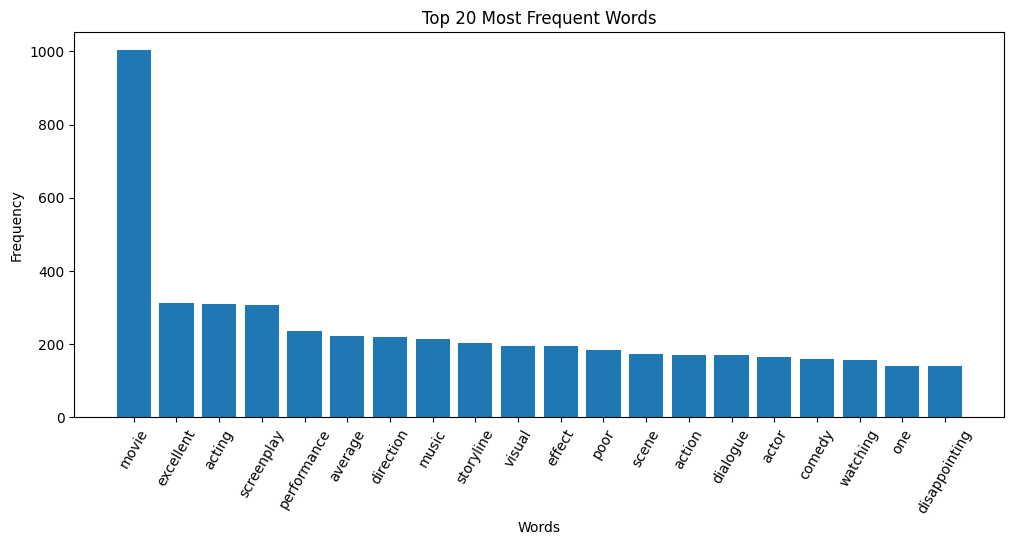

In [58]:
plt.figure(figsize=(12,5))

plt.bar(
    top20_df["Word"],
    top20_df["Frequency"]
)
plt.xticks(rotation=60)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [59]:
# AUDIENCE OPINIONS ANALYSIS

positive_reviews = len(df[df["Sentiment"]=="Positive"])
negative_reviews = len(df[df["Sentiment"]=="Negative"])
neutral_reviews = len(df[df["Sentiment"]=="Neutral"])
print("Positive Reviews :", positive_reviews)
print("Negative Reviews :", negative_reviews)
print("Neutral Reviews :", neutral_reviews)

Positive Reviews : 500
Negative Reviews : 300
Neutral Reviews : 200


In [60]:
average_rating = df["Rating"].mean()
print("Average Movie Rating :", round(average_rating,2))

Average Movie Rating : 3.31


In [61]:
print("Most Common Words Used:")
top20_df.head(10)

Most Common Words Used:


,Word,Frequency
0,movie,1003
1,excellent,312
2,acting,309
3,screenplay,307
4,performance,234
5,average,221
6,direction,220
7,music,212
8,storyline,203
9,visual,194


In [62]:
# FINAL REPORT

print("="*60)
print("MOVIE REVIEW CLASSIFICATION REPORT")
print("="*60)
print()
print(f"Total Reviews : {len(df)}")
print()
print(f"Positive Reviews : {positive_reviews}")
print(f"Negative Reviews : {negative_reviews}")
print(f"Neutral Reviews : {neutral_reviews}")
print()
print(f"Average Rating : {round(average_rating,2)}")
print()
print("Model Accuracy : {:.2f}%".format(accuracy*100))
print()
print("Top Frequently Used Words")
print(top20_df.head(10))
print()
print("="*60)

MOVIE REVIEW CLASSIFICATION REPORT

Total Reviews : 1000

Positive Reviews : 500
Negative Reviews : 300
Neutral Reviews : 200

Average Rating : 3.31

Model Accuracy : 100.00%

Top Frequently Used Words
          Word  Frequency
0        movie       1003
1    excellent        312
2       acting        309
3   screenplay        307
4  performance        234
5      average        221
6    direction        220
7        music        212
8    storyline        203
9       visual        194



In [63]:
# RECOMMENDATIONS

recommendations = [
"Produce more movies with engaging storylines.",
"Focus on improving screenplay and direction.",
"Improve acting quality where audience feedback is negative.",
"Enhance visual effects for better viewer experience.",
"Continue producing content similar to highly-rated movies."
]
for i, rec in enumerate(recommendations,1):
    print(f"{i}. {rec}")

1. Produce more movies with engaging storylines.
2. Focus on improving screenplay and direction.
3. Improve acting quality where audience feedback is negative.
4. Enhance visual effects for better viewer experience.
5. Continue producing content similar to highly-rated movies.
